Practice 4

4. Using cross_val_score, find the best max_depth for the Decision Tree among [2, 3, 4, 5, 6, 8, 10, None] with cv=5. Compare to the fixed max_depth=4 tree used above. Plot CV accuracy against max_depth (treat None as, say, 12 so it fits on the axis).


In [15]:
# Import the libraries needed to load the dataset, split the data, train the Decision Tree, perform cross-validation, and measure accuracy.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

Cell 2

In [16]:
# Load the Breast Cancer dataset into a pandas DataFrame.

data = load_breast_cancer(as_frame=True)

df = data.frame

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


Cell 3

In [17]:
# X contains the features and y contains the target.

X = df.drop(columns="target")
y = df["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (569, 30)
y shape: (569,)


Cell 4

In [18]:
# Split the data into training and test sets while preserving the class proportions.

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (455, 30)
Test size: (114, 30)


Cell 5

In [19]:
# Train the fixed Decision Tree with max_depth=4 as the baseline model.

tree_fixed = DecisionTreeClassifier( max_depth=4, random_state=42)

tree_fixed.fit(X_train, y_train)

y_pred_fixed = tree_fixed.predict(X_test)

fixed_accuracy = accuracy_score(y_test,y_pred_fixed)

print("Fixed max_depth=4 accuracy:", round(fixed_accuracy, 4))

Fixed max_depth=4 accuracy: 0.9386


Cell 6

In [20]:
# Test the specified max_depth values from the exercise.

depths = [2, 3, 4, 5, 6, 8, 10, None]

print(depths)

[2, 3, 4, 5, 6, 8, 10, None]


Cell 7

In [21]:
# For each max_depth, calculate the mean five-fold cross-validation accuracy.

cv_scores = []

for depth in depths:
    model = DecisionTreeClassifier(max_depth=depth,random_state=42)

    scores = cross_val_score(model,X_train,y_train,cv=5,scoring="accuracy")

    cv_scores.append(scores.mean())

print("CV scores:")
print(cv_scores)

CV scores:
[np.float64(0.9186813186813186), np.float64(0.9252747252747252), np.float64(0.9384615384615385), np.float64(0.9318681318681318), np.float64(0.9186813186813186), np.float64(0.9098901098901099), np.float64(0.9098901098901099), np.float64(0.9098901098901099)]


Cell 8

In [22]:
# Compare the cross-validation accuracy of all tested depths.

for depth, score in zip(depths, cv_scores):
    print("max_depth =", depth,"CV accuracy =", round(score, 4))

max_depth = 2 CV accuracy = 0.9187
max_depth = 3 CV accuracy = 0.9253
max_depth = 4 CV accuracy = 0.9385
max_depth = 5 CV accuracy = 0.9319
max_depth = 6 CV accuracy = 0.9187
max_depth = 8 CV accuracy = 0.9099
max_depth = 10 CV accuracy = 0.9099
max_depth = None CV accuracy = 0.9099


Cell 9

In [23]:
# Choose the max_depth with the highest mean cross-validation accuracy.

best_index = np.argmax(cv_scores)

best_depth = depths[best_index]
best_cv_accuracy = cv_scores[best_index]

print("Best max_depth:", best_depth)
print("Best CV accuracy:", round(best_cv_accuracy, 4))

Best max_depth: 4
Best CV accuracy: 0.9385


Cell 10

In [24]:
# Compare the fixed max_depth=4 model with the best depth found by cross-validation.

print("Fixed max_depth=4 accuracy:", round(fixed_accuracy, 4))
print("Best max_depth:", best_depth)
print("Best CV accuracy:", round(best_cv_accuracy, 4))

Fixed max_depth=4 accuracy: 0.9386
Best max_depth: 4
Best CV accuracy: 0.9385


Cell 11

In [25]:
# Represent max_depth=None as 12 only for plotting.

depths_plot = []

for depth in depths:
    if depth is None:
        depths_plot.append(12)
    else:
        depths_plot.append(depth)

print(depths_plot)

[2, 3, 4, 5, 6, 8, 10, 12]


Cell 12

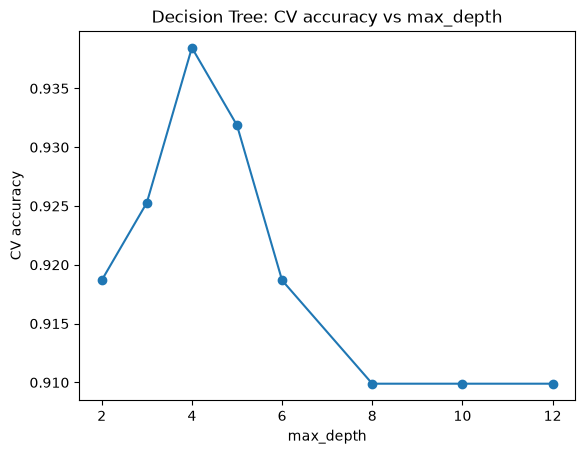

In [26]:
# Plot cross-validation accuracy against max_depth.

plt.plot(depths_plot,cv_scores,marker="o")

plt.xlabel("max_depth")
plt.ylabel("CV accuracy")
plt.title("Decision Tree: CV accuracy vs max_depth")
plt.show()

Cell 13

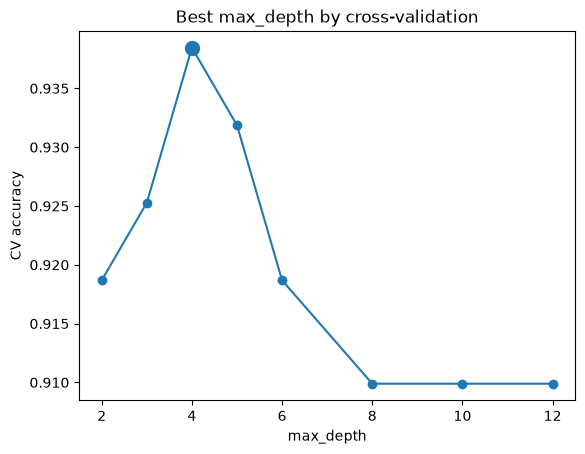

In [27]:
# Highlight the depth that achieved the highest cross-validation accuracy.

plt.plot(depths_plot,cv_scores,marker="o")

plt.scatter(depths_plot[best_index],best_cv_accuracy,s=100)

plt.xlabel("max_depth")
plt.ylabel("CV accuracy")
plt.title("Best max_depth by cross-validation")
plt.show()

Cell 14

In [34]:
# Report the baseline accuracy, the best max_depth, and its cross-validation accuracy.

print("-" * 32)
print("Decision Tree Exercise 4")
print("-" * 32)

print("Fixed max_depth=4 accuracy:",
      round(fixed_accuracy, 4))

print("Best max_depth:",
      best_depth)

print("Best CV accuracy:",
      round(best_cv_accuracy, 4))

--------------------------------
Decision Tree Exercise 4
--------------------------------
Fixed max_depth=4 accuracy: 0.9386
Best max_depth: 4
Best CV accuracy: 0.9385
